# Fraud Transaction Detection

The dataset used consists of financial transactions intended for building a fraud detection model.

Each row in the dataset represents a single transaction containing various information, such as:
1.  step           = Indicates the time sequence or period of the transaction within the dataset.
2.  type           = Indicates the type of transaction.
3.  amount         = Indicates the monetary amount of the transaction.
4.  nameOrig       = Indicates the ID of the account or user initiating the transaction.
5.  oldbalanceOrg  = Indicates the sender's account balance before the transaction.
6.  newbalanceOrig = Indicates the sender's account balance after the transaction.
7.  nameDest       = Indicates the ID of the recipient's account.
8.  oldbalanceDest = Indicates the recipient's account balance before the transaction.
9.  newbalanceDest = Indicates the recipient's account balance after the transaction.
10. isFlaggedFraud = Indicates whether the transaction was flagged or detected by the system as fraud based on specific rules.
11. isFraud        = The label or target variable the model aims to predict.

There are five types of transactions:
1. TRANSFER = Moving money from one account to another
2. CASH_OUT = Withdrawing or cashing out funds from an account
3. CASH_IN  = Depositing funds into an account
4. DEBIT    = A debit transaction or balance deduction, such as a specific payment
5. PAYMENT  = A payment transaction

These features serve as predictor variables, while isFraud acts as the label or target.

The isFraud label consists of two classes: 0 for non-fraudulent transactions and 1 for fraudulent transactions. Consequently, this problem falls under supervised learning—specifically binary classification—with the objective of predicting whether a transaction is fraudulent or non-fraudulent.

## Import 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# mengatur tampilan dan menghilangkan pesan peringatan (warning)
# FutureWarning: ...
# UserWarning: ...
# DeprecationWarning: ...

In [3]:
df = pd.read_csv('./AIML Dataset.csv')

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Exploratory Data Analyst

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

### Number of null data

In [7]:
df.isnull().sum()
# cek nul tiap kolom

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.isnull().sum().sum()
# cek nul tiap keseluruhan

0

### Number of duplicate data

In [9]:
df.duplicated().sum()

0

In [10]:
df.shape

(6362620, 11)

### Number of fraud data

In [11]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [13]:
# persentase penipuan
# jumlah baris yg fraud / jumlah baris keseluruhan
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100, 2)

0.13

In [14]:
df["type"].value_counts()[0]

2237500

### Number of transactions by transaction type

In [15]:
# Visualisasi

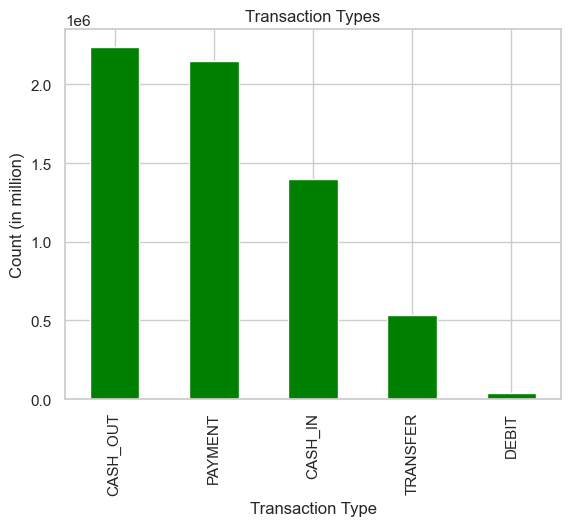

In [16]:
# Jumlah transaksi bedasarkan tipe traksaksi
df["type"].value_counts().plot(
    kind="bar", 
    title="Transaction Types", 
    color = "green"
)

plt.xlabel("Transaction Type")
plt.ylabel("Count (in million)")
plt.show()

### Average fraud transaction value by transaction type

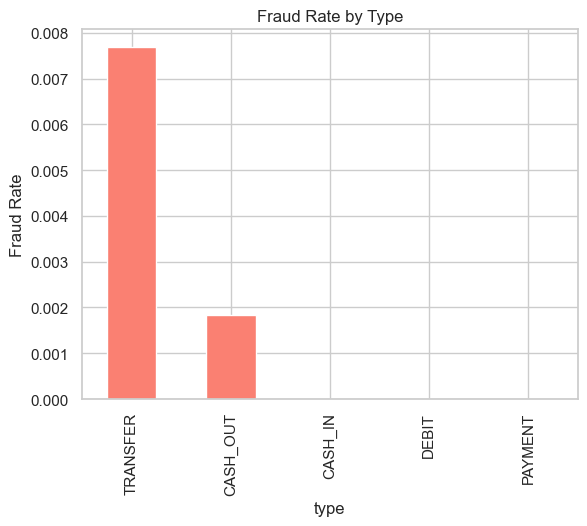

In [17]:
# rata-rata traksaksi fraud bedasarkan tipe transaksi
# jumlah traksaksi fraud per tipe / jumlah transaksi per tipe
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [18]:
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

### Statistics for the amount

#### Statistic

In [19]:
# cek statistik kolom amount
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int32

#### Distribution of amount

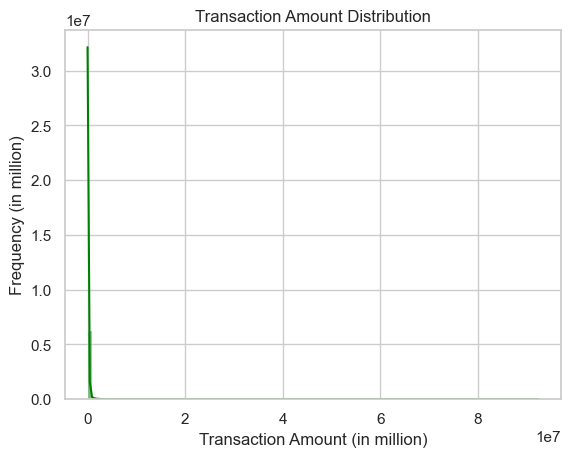

In [20]:
# cek distribusi amount
sns.histplot(
    df["amount"],
    bins=100,
    kde=True,
    color="green"
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (in million)")
plt.ylabel("Frequency (in million)")
plt.show()

- many small-value transactions
- but some transactions have very large values
- consequently, the distribution is highly skewed

Check the distribution of the amount using a log transformation to address the highly skewed distribution

#### Distribution of amount (log scale)

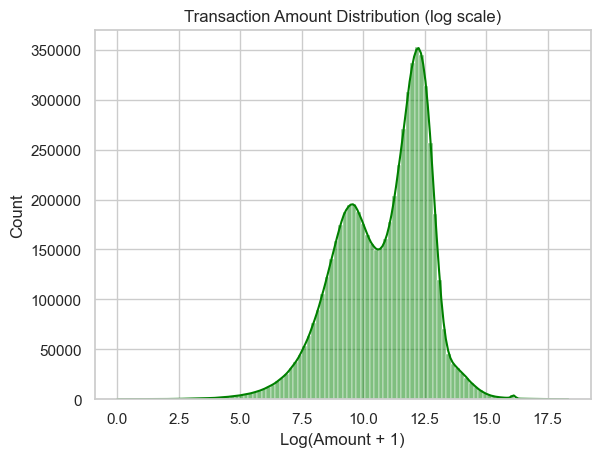

In [21]:
# cek distribusi amount pake transformasi log
# untuk mengatasi distribusi yg sangat miring (skewed)
sns.histplot(np.log1p(df["amount"]), bins=100, kde = True, color = "green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

#### Boxplot between amount vs isFraud

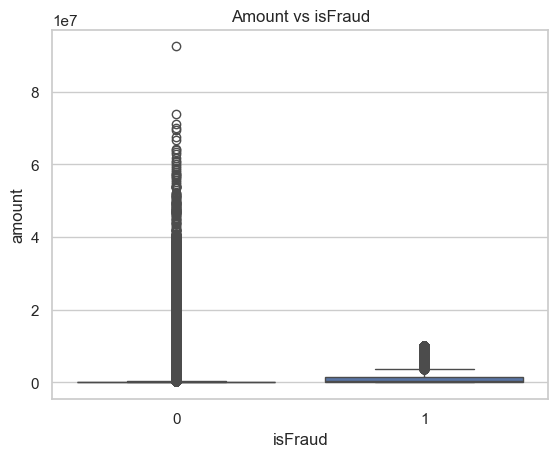

In [22]:
# cek boxplot
sns.boxplot(data = df, x = "isFraud", y = "amount")
plt.title("Amount vs isFraud")
plt.show()

The scale of non-fraud transactions (isFraud = 0) is much larger and includes many outliers.

> For isFraud = 0:
- Most transactions relatively low value range.
- There are many data points far above the box.
- Some transactions even reach around 90 million.
- This indicates that the transaction amount distribution for non-fraud transactions is heavily right-skewed and contains extreme values.

> For isFraud = 1:
- Fraud transaction values appear more concentrated.
- There are also outliers.
- Values reach around 10 million, but do not go as high as some non-fraud transactions.

> FYI:
- 1e7 = 10^7 = 10,000,000

#### Boxplot filter outlier between amount vs isFraud

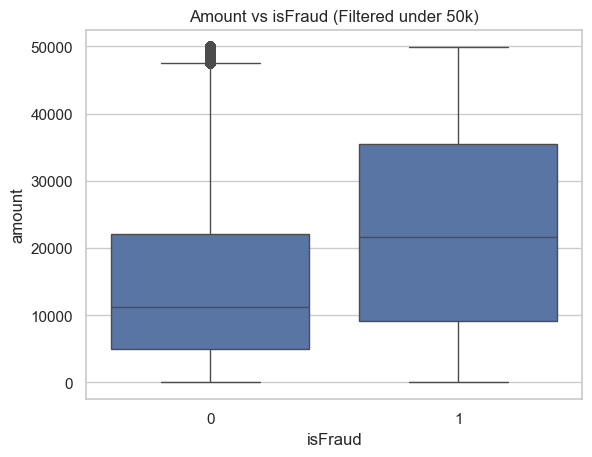

In [23]:
# cek boxplot (filter)
sns.boxplot(data= df[df["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

#### Boxplot (log scale) between amount vs isFraud

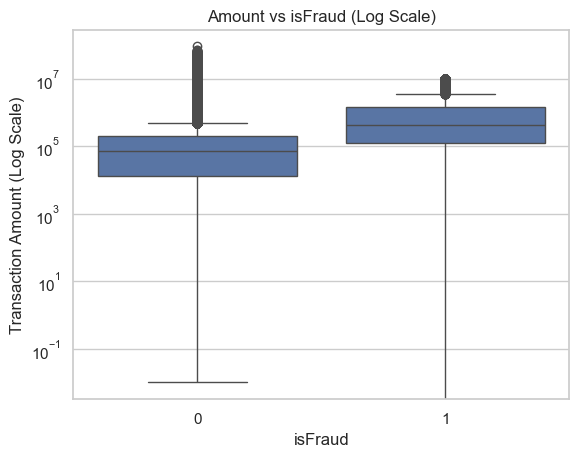

In [24]:
# cek boxplot (dengan skala logaritmik)
# 10, 100, 1000, 10000, dst
sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
    
)

plt.yscale("log")
plt.title("Amount vs isFraud (Log Scale)")
plt.xlabel("isFraud")
plt.ylabel("Transaction Amount (Log Scale)")
plt.show()

### Is a step column required?

In [25]:
# # Check if the 'step' column is needed

#               STEP
#                │
#                ▼
#      
#            Visualization      
# ┌────────────┬────────────┬────────────┐
# │   count    │    sum     │   mean     │
# │            │            │            │
# │Total       │Total       │Fraud       │
# │Transactions│Fraud       │Rate        │
# └────────────┴────────────┴────────────┘
#                │
#                ▼
#       ┌──────────────────┐
#       │ Correlation      │
#       │ step vs isFraud  │
#       └────────┬─────────┘
#                │
#                ▼
#        Feature decision
#        drop/keep

In [26]:
# Fraud visualization workflow by step

# Dataset                         -> df
#    ↓
# Select isFraud = 1               -> df["isFraud"] == 1
#    ↓
# Select the 'step' column         -> ["step"]
#    ↓
# Count fraud occurrences per step -> .value_counts()
#    ↓
# Sort by step                     -> .sort_index()
#    ↓
# Create a line chart              -> plt.plot(...)

In [27]:
# # Fraud rate visualization workflow by step
#                  DATAFRAME
#                      │
#                      ▼
#               ┌─────────────┐
#               │ groupby     │
#               │    step     │
#               └──────┬──────┘
#                      │
#                      ▼
#               Each group
#                 based on
#                    step
#                      │
#                      ▼
#               ┌─────────────┐
#               │   isFraud   │
#               └──────┬──────┘
#                      │
#           ┌──────────┼──────────┐
#           ▼          ▼          ▼
#        count()     sum()      mean()
# example:(1,1,0)=3  (1,1,0)=2 (1,1,0)=2/3=0.67
#           │          │          │
#           ▼          ▼          ▼
#        Total       Total      Fraud
#      Transactions  Fraud       Rate
#           │          │          │
#           └──────────┼──────────┘
#                      ▼
#               summary_step

In [28]:
summary_step = df.groupby("step")["isFraud"].agg(
    total_transactions="count",
    total_fraud="sum",
    fraud_rate="mean"
)

summary_step

,total_transactions,total_fraud,fraud_rate
step,,,
1,2708,16,0.005908
2,1014,8,0.007890
3,552,4,0.007246
4,565,10,0.017699
5,665,6,0.009023
...,...,...,...
739,10,10,1.000000
740,6,6,1.000000
741,22,22,1.000000


In [29]:
summary_step["total_transactions"]

step
1      2708
2      1014
3       552
4       565
5       665
       ... 
739      10
740       6
741      22
742      14
743       8
Name: total_transactions, Length: 743, dtype: int64

#### Transaction per step

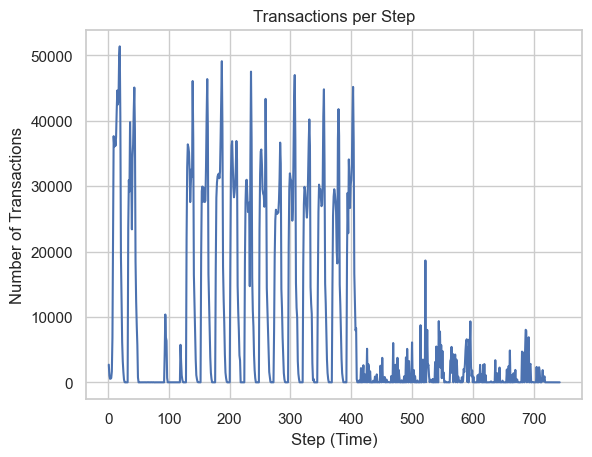

In [30]:
# visualisasi total transaksi tiap waktu
plt.plot(summary_step.index, summary_step["total_transactions"], label="Transactions per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Transactions")
plt.title("Transactions per Step")
plt.grid(True)
plt.show()

#### Fraud transactions per step

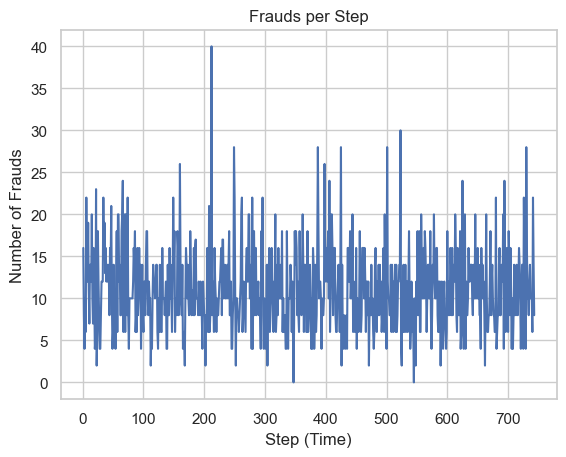

In [31]:
# visualisasi total fraud tiap waktu
plt.plot(summary_step.index, summary_step["total_fraud"], label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds per Step")
plt.grid(True)
plt.show()

### Fraud transaction rate per step

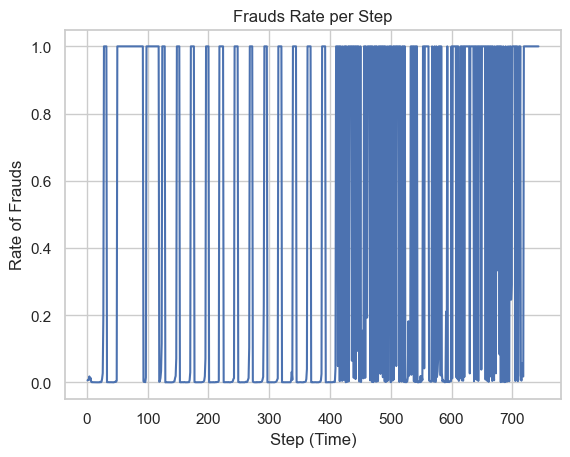

In [32]:
# visualisasi rate fraud tiap waktu
plt.plot(summary_step.index, summary_step["fraud_rate"], label="Frauds Rate per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Rate of Frauds")
plt.title("Frauds Rate per Step")
plt.grid(True)
plt.show()

#### Corellation between step vs isFraud

In [33]:
# korelasi step vs isFraud
df[["step", "isFraud"]].corr()

,step,isFraud
step,1.000000,0.031578
isFraud,0.031578,1.000000


- Visualizations of the number and rate of fraud transactions on each step reveal no have a trend.
- Furthermore, correlation analysis shows a weak relationship between the 'step' feature and 'isFraud'.
- Therefore, the 'step' feature can be removed.

Drop the column of step

In [34]:
# hapus kolom step
df.drop(columns="step",inplace=True)

In [35]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Top senders

In [36]:
# cek jumlah pengirim teratas
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

There is no information yet.

### Top receivers

In [37]:
# cek jumlah penerima teratas
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

There is no information yet

### Top fraud receivers

In [38]:
# cek jumlah penerima teratas yang fraud
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

There is no information yet

### Fraud transaction in transfer and cashout type

because the highest incidence of fraud occurs in the "Transfer" and "Cash_Out" categories

In [39]:
# ambil hanya tipe "Transfer" dan "Cash_Out"
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0


In [40]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

#### Number of fraud data points in each category

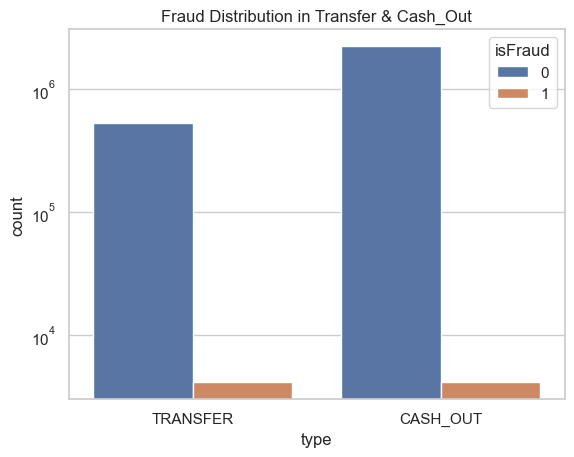

In [41]:
# jumlah data pada setiap kategori
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.yscale("log")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

The difference between the number of fraud and non-fraud cases within that category remains very significant.

### Corellation columns

In [42]:
# matriks korelasi
corr = df[["amount",
           "oldbalanceOrg",
           "newbalanceOrig",
           "oldbalanceDest",
           "newbalanceDest"
          ]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000


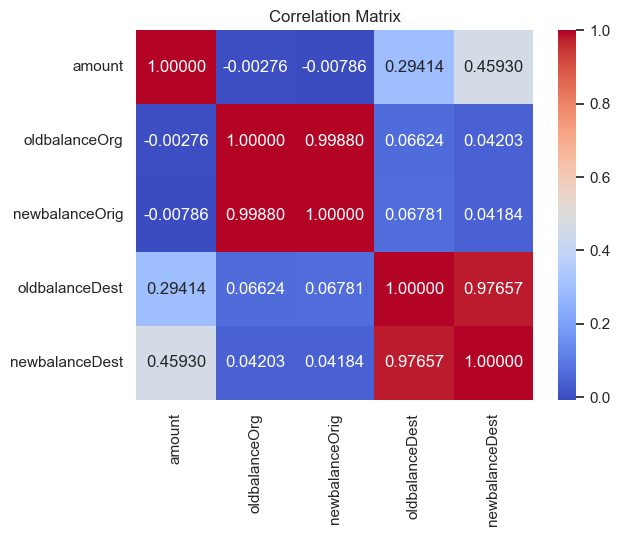

In [43]:
# visualisasi dengan heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".5f")
plt.title("Correlation Matrix")
plt.show()

In [44]:
# # amount vs oldbalanceOrg
# Pada data normal, amount memiliki korelasi positif dengan oldbalanceOrg (ex: 0.99). 
# Artinya, jika pengguna mengirim uang dalam jumlah besar (+), maka mereka memang memiliki saldo awal yang besar (+).
# tetapi dalam kasus kita korelasi hanya -0.0001, artinya belum mungking berlaku sebaliknya
# belum tentu jika mereka memiliki saldo awal yang besar (+), maka pengguna mengirim uang dalam jumlah besar (+)
# contoh:
# 1. saldo budi awal = 1jt, transfer amount = 900k
# 2. saldo andi awal = 1jt, transfer amount = 25k

# # amount vs newbalanceOrg
# Pada data normal terdapat korelasi negatif antara amount dan newbalanceOrig (ex: -0.99)
# Artinya, jika saldo akhir pengirim berkurang banyak (-), maka nominal amount yang dikirim besar (+)
# tetapi dalam kasus kita korelasi hanya -0.0001, artinya belum mungkin berlaku sebaliknya
# belum tentu jika nominal amount yang dikirim besar (+), maka saldo akhir pengirim berkurang banyak (-)
# contoh:
# 1. transfer amount = 900k, saldo budi akhir = 100k
# 2. transfer amount = 25k, saldo andi akhir = 975k

# # amount vs newbalanceDest
# Pada data normal terdapat korelasi positif antara amount dan newbalanceOrig (ex: 0.99)
# Artinya, jika uang yang diterima besar (+), maka saldo akhir penerima juga besar (+)
# dalam kasus kita korelasi hanya 0.46 (positif), ini cukup bagus dan mungkin berlaku sebaliknya
# artinya jika saldo akhir penerima besar (+), maka mungkin untuk uang yang diterima (amount) juga besar (+)

# # amount vs oldbalanceDest
# tidak perlu korelasi sangat kuat positif atau negatif
# penerima tidak perlu memiliki saldo banyak untuk di transfer banyak
# dsb



In [45]:
# # amount vs oldbalanceOrg
# In normal data, 'amount' has a positive correlation with 'oldbalanceOrg' (e.g., 0.99).
# This means that if a user sends a large amount of money (+), they indeed have a large initial balance (+).
# However, in our case, the correlation is only -0.0001, meaning the reverse does not necessarily hold true.
# Having a large initial balance (+) does not guarantee that the user will send a large amount of money (+).
# Examples:
# 1. Budi's initial balance = 1M, transfer amount = 900k
# 2. Andi's initial balance = 1M, transfer amount = 25k

# # amount vs newbalanceOrg
# In normal data, there is a negative correlation between 'amount' and 'newbalanceOrig' (e.g., -0.99).
# This means that if the sender's final balance decreases significantly (-), the transferred amount is large (+).
# However, in our case, the correlation is only -0.0001, meaning the reverse does not necessarily hold true.
# A large transferred amount (+) does not guarantee a significant decrease (-) in the sender's final balance.
# Examples:
# 1. Transfer amount = 900k, Budi's final balance = 100k
# 2. Transfer amount = 25k, Andi's final balance = 975k

# # amount vs newbalanceDest
# In normal data, there is a positive correlation between 'amount' and 'newbalanceOrig' (e.g., 0.99).
# This means that if the money received is a large amount (+), the recipient's final balance is also large (+).
# In our case, the correlation is 0.46 (positive); this is quite good, and the reverse may hold true.
# This implies that if the recipient's final balance is large (+), the amount received is likely large (+) as well.

# # amount vs oldbalanceDest
# A very strong positive or negative correlation is not required here.
# The recipient does not need to have a large balance to receive a large transfer.
# Etc.

### A transaction where the sender's remaining balance is zero

In [46]:
# transaksi dimana pengirim sisa saldonya = 0
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    df["type"].isin(["TRANSFER","CASH_OUT"])
]
len(zero_after_transfer)

1188074

In [47]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0


In [48]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## Model

### Import 2

In [49]:
from sklearn.model_selection import train_test_split   
from sklearn.preprocessing import StandardScaler      
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [50]:
# train_test_split = module for splitting training and testing data
# StandardScaler = module for scaling data
# LogisticRegression = module for modeling
# classification_report, confusion_matrix = model evaluation modules
# Pipeline = module for chaining multiple machine learning process stages
# example:
# pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", SVC())
# ])
# resulting in
#               PIPELINE
#                  │
#                  ▼
#              Data X
#                  │
#                  ▼
#         ┌─────────────────┐
#         │ StandardScaler  │
#         └────────┬────────┘
#                  │
#                  ▼
#         ┌─────────────────┐
#         │      SVC        │
#         └────────┬────────┘
#                  │
#                  ▼
#              Prediction

# ColumnTransformer = manages preprocessing based on column type
# example:
# age, income
#     ↓
# StandardScaler

# gender, city
#     ↓
# OneHotEncoder

# OneHotEncoder = converts categorical data (text/categories) into numerical form

### Creating a dataframe for modeling

In [51]:
# menghapus kolom yang tidak perlu
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)
df_model.head()

# axis = 1, hapus kolom
# axis = 0, hapus baris

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


### Categorize columns based on data type.

In [52]:
# kategorikan kolom bedasarkan tipe data
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

### input X dan y for modelling

In [53]:
# input X dan y untuk dimodelkan
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

### Split the data

In [54]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y
)
# stratify = y -> agar y_train dan y_test ter split sempurna
# fraud dan bukan fraud ke split 70% - 30%

### Preprocessing

In [55]:
# Preprocessing workflow
#                        X
#                        │
#               ┌────────┴────────┐
#               │                 │
#        Numerical columns   Categorical columns
#               │                 │
#               ↓                 ↓
#       StandardScaler()    OneHotEncoder()
#               │                 │
#               ↓                 ↓
#      Standardized data     0 and 1 data
#               │                 │
#               └────────┬────────┘
#                        ↓
#               Preprocessing result
#                        │
#                        ↓
#                  Machine Learning
#                       Model

In [56]:
# Preprocessing numerical and categorical features differently 
# before feeding the data into the machine learning model
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder = "drop"
)


# ColumnTransformer(...) = applies different transformations to different columns
# transformers = list of transformations to be performed
# general format: transformers = [("transformation_name", transformation_method, columns_to_process), ...]
# StandardScaler() and OneHotEncoder() are examples of preprocessing methods
# OneHotEncoder(drop="first") = drops one category; often used to avoid the dummy variable trap / perfect multicollinearity, especially in linear models.
# remainder="drop" = columns not specified in the numeric or categorical lists will be dropped.

### Pipeline

In [57]:
# Pipeline Flow
#        X_train
#           │
#           ▼
# ┌─────────────────────┐
# │        prep         │
# │ ColumnTransformer   │
# │                     │
# │ Numerical → Scaling │
# │ Category → One-Hot  │
# └──────────┬──────────┘
#            │
#            ▼
# ┌─────────────────────┐
# │        clf          │
# │ Logistic Regression │
# │                     │
# │    class_weight=    │
# │     "balanced"      │
# └──────────┬──────────┘
#            │
#            ▼
#        Prediction

In [58]:
# Pipeline
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])


# class_weight="balanced"   -> Logistic Regression assigns greater weight to the minority class (fraud)
# max_iter=1000             -> The model is allowed a maximum of 1000 iterations to find a solution
# Start
#   ↓
# Find the best parameters
#   ↓
# Refine parameters
#   ↓
# Refine further
#   ↓
# ...
#   ↓
# Stop upon convergence or reaching the limit (1000 iterations)

### Training Model

In [59]:
# Training model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest', 'newbalanceDest']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

### Prediction

In [60]:
# Prediksi model
y_pred = pipeline.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

### Model evaluation

#### Classification report

In [62]:
# classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.93      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [63]:
# Hasil 
# 1. Model memperoleh accuracy sebesar 95%.
# 2. Model memiliki performa yang sangat baik dalam mengklasifikasikan transaksi non-fraud dengan 
#    + precision sebesar 1.00
#    + recall sebesar 0.95
#    + F1-score sebesar 0.97
# 3. Model memiliki performa yang kurang baik pada kelas Fraud
#    - precision sebesar 0.02
#    + recall sebesar 0.94
#    - F1-score sebesar 0.04
# 4. Hal ini menunjukkan bahwa model mampu mendeteksi sebagian besar transaksi fraud (recall yang tinggi)
# 5. Tetapi menghasilkan jumlah false positive yang sangat tinggi (precision yang rendah)
# 6. Rendahnya F1-score kelas fraud sebesar 0,04 juga menunjukkan bahwa performa klasifikasi fraud belum optimal.
# 7. Kondisi tersebut kemungkinan besar dipengaruhi oleh ketidakseimbangan kelas yang sangat besar antara transaksi non-fraud dan fraud.
# support(0) = data Non-Fraud = 1.906.322
# support(1) = data Fraud     =     2.464

# Kesimpulan
# Accuracy sebesar 95% belum dapat dijadikan indikator utama bahwa model memiliki performa yang baik dalam mendeteksi fraud.

In [81]:
# Results
# 1. The model achieved an accuracy of 95%.
# 2. The model performed very well in classifying non-fraud transactions, with:
#    + precision of 1.00
#    + recall of 0.95
#    + F1-score of 0.97
# 3. The model performed poorly on the Fraud class:
#    - precision of 0.02
#    + recall of 0.94
#    - F1-score of 0.04
# 4. This indicates that the model is capable of detecting the majority of fraud transactions (high recall).
# 5. However, it produces a very high number of false positives (low precision).
# 6. The low F1-score of 0.04 for the fraud class also indicates that fraud classification performance is not yet optimal.
# 7. This situation is likely driven by the significant class imbalance between non-fraud and fraud transactions.
# support(0) = Non-Fraud data = 1,906,322
# support(1) = Fraud data     =     2,464

# Conclusion
# An accuracy of 95% cannot be used as the primary indicator that the model performs well in detecting fraud.

#### Confusion matriks

In [64]:
# confusion matriks
confusion_matrix(y_test, y_pred)

array([[1805598,  100724],
       [    174,    2290]], dtype=int64)

In [82]:
# [TN, FP]
# [FN, TP]

# The number of False Positives is very high: 104,155 data points
# This means the model predicted non-fraud cases as fraud
# Actual = 0, Prediction = 1

### How to increase precision?

In [83]:
# We will attempt to increase precision

# Fraud precision is low because False Positives (FP) are very high.
# Precision = TP / (TP + FP)

# Key strategy
# Reduce the number of non-fraud transactions incorrectly predicted as fraud

In [67]:
# Adjusting the classification threshold
# Logistic Regression typically uses:
#        P(Fraud) ≥ 0.5 ⇒ Fraud
# Raising the threshold from 0.5 to 0.7 makes the model more selective in classifying transactions as fraud
# | Fraud Probability | Threshold 0.5 | Threshold 0.7 |
# | -----------------: | ------------- | ------------- |
# |               0.30 | Non-Fraud     | Non-Fraud     |
# |               0.55 | Fraud         | Non-Fraud     |
# |               0.65 | Fraud         | Non-Fraud     |
# |               0.75 | Fraud         | Fraud         |
# |               0.90 | Fraud         | Fraud         |


# Consequences:
#    False Positives ↓
#    Precision ↑
#    Recall ↓

# We sacrifice some recall to achieve better precision

In [68]:
# Workflow for comparing model evaluation results based on threshold parameters
#                  X_test
#                     │
#                     ▼
#          pipeline.predict_proba()
#                     │
#                     ▼
#          Fraud class probabilities
#                     │
#                     ▼
#       ┌─────────────────────────┐
#       │ Try threshold 0.10      │
#       │ Try threshold 0.15      │
#       │ Try threshold 0.20      │
#       │ ...                     │
#       │ Try threshold 0.95      │
#       └─────────────────────────┘
#                     │
#                     ▼
#         Convert probabilities to
#              0 / 1 predictions
#                     │
#                     ▼
#          classification_report()
#                     │
#           ┌─────────┼─────────┐
#           ▼         ▼         ▼
#       Precision   Recall    F1-score
#           │         │         │
#           └─────────┼─────────┘
#                     ▼
#                 DataFrame
#                     │
#                     ▼
#           Compare thresholds

#### Finding the best threshold parameters

In [69]:
from sklearn.metrics import classification_report
import numpy as np

# Probabilitas kelas Fraud
y_prob = pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.05)

hasil_threshold = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    report = classification_report(
        y_test,
        y_pred_threshold,
        output_dict=True,
        zero_division=0
    )
    
    hasil_threshold.append({
        "threshold": threshold,
        "precision_fraud": report["1"]["precision"],
        "recall_fraud": report["1"]["recall"],
        "f1_fraud": report["1"]["f1-score"]
    })

hasil_threshold = pd.DataFrame(hasil_threshold)

hasil_threshold


,threshold,precision_fraud,recall_fraud,f1_fraud
0,0.10,0.005265,0.996753,0.010474
1,0.15,0.006312,0.996347,0.012545
2,0.20,0.007532,0.994318,0.014950
3,0.25,0.009036,0.992695,0.017909
4,0.30,0.010962,0.990666,0.021685
5,0.35,0.013467,0.988231,0.026572
6,0.40,0.016258,0.973214,0.031983
7,0.45,0.019192,0.950893,0.037624
8,0.50,0.022230,0.929383,0.043421
9,0.55,0.025764,0.912338,0.050113


#### Evaluation model per threshold

In [70]:
# sorting descending bedasarkan f1-score fraud
hasil_threshold.sort_values(
    "f1_fraud",
    ascending=False
).head(10)

,threshold,precision_fraud,recall_fraud,f1_fraud
17,0.95,0.161993,0.682224,0.261818
16,0.90,0.104994,0.734578,0.183728
15,0.85,0.078189,0.775162,0.142050
14,0.80,0.062243,0.816964,0.115673
13,0.75,0.051317,0.851867,0.096802
12,0.70,0.041952,0.865666,0.080026
11,0.65,0.035064,0.879058,0.067439
10,0.60,0.029782,0.894075,0.057643
9,0.55,0.025764,0.912338,0.050113
8,0.50,0.022230,0.929383,0.043421


#### Prediction with new threshold

In [71]:
# Prediksi dengan threshold = 0.95

In [72]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [73]:
# y_pred_try dengan threshold = 0.95
threshold = 0.97

y_pred_try = (y_prob >= threshold).astype(int)
y_pred_try

array([0, 0, 0, ..., 0, 0, 0])

In [74]:
# confusion matriks dengan threshold = 0.95
confusion_matrix(y_test, y_pred_try)

array([[1900480,    5842],
       [    861,    1603]], dtype=int64)

### Compare model

In [75]:
# [TN, FP]
# [FN, TP]

# Bandingkan

# Threshold = 0.50
# [[1802167,  104155],
#  [    155,    2309]

# Threshold = 0.95
# [[1900032,    6290],
#  [    859,    1605]]

# Walau FP terlihat turun, tetapi FN nya justru naik
# Dalam kasus fraud detection, umumnya harus lebih toleran terhadap False Positive (FP) dan sangat ketat (tidak toleran) terhadap False Negatif (FN)

# Apa yang terjadi?
# False Negatif -> actual=fraud,       pred=bukan_fraud
# False Positif -> actual=bukan_fraud  pred=fraud

# Dampak
# FN -> Sangat Fatal. Perusahaan kehilangan uang secara langsung
# FP -> Akun nasabah mungkin terkunci sementara

# Hasil
# FN -> Harus diminimalisir semaksimal mungkin
# FP -> Lebih baik salah memblokir orang jujur daripada meloloskan penipu

# Kesimpulan
# Kita pakai Threshold = 0.50

In [84]:
# [TN, FP]
# [FN, TP]

# Comparison

# Threshold = 0.50
# [[1802167,  104155],
#  [    155,    2309]

# Threshold = 0.95
# [[1900032,    6290],
#  [    859,    1605]]

# Although FPs appear to decrease, FNs actually increase.
# In fraud detection cases, one generally needs to be more tolerant of False Positives (FP) and very strict (intolerant) regarding False Negatives (FN).

# What is happening?
# False Negative -> actual=fraud,       pred=not_fraud
# False Positive -> actual=not_fraud,    pred=fraud

# Impact
# FN -> Very critical. The company suffers direct financial loss.
# FP -> Customer account might be temporarily locked.

# Outcome
# FN -> Must be minimized as much as possible.
# FP -> It is better to mistakenly block an honest person than to let a fraudster through.

# Conclusion
# We use Threshold = 0.50.

In [76]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

## Save model/papeline

In [77]:
# Simpan model/papeline

In [78]:
import joblib

joblib.dump(pipeline, 'fraud_detection_pipeline.joblib')

['fraud_detection_pipeline.joblib']

In [79]:
# jika ingin pakai pipeline untuk data test baru

In [80]:
# model_siap_pakai = joblib.load('fraud_detection_pipeline.joblib')